In [67]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import func_stats as fs
import func_plot as fp
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings("ignore")

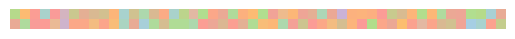

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LinearSegmentedColormap

# Base data
data = np.random.rand(2, 50)

# Smooth it (removes harsh edges)
smooth = gaussian_filter(data, sigma=3)

# Add subtle texture (noise)
texture = smooth + 0.1 * np.random.randn(2, 50)

# Monet-style colors
colors = ["#a6cee3", "#b2df8a", "#fb9a99", "#fdbf6f", "#cab2d6"]
monet_cmap = LinearSegmentedColormap.from_list("monet", colors)

plt.imshow(texture, cmap=monet_cmap)
plt.axis("off")
plt.show()

In [15]:
texture[texture.argsort(axis=0)]

array([[[0.2504577 , 0.48656239, 0.39567869, ..., 0.40120945,
         0.3463471 , 0.42077797],
        [0.32148805, 0.22518618, 0.39138856, ..., 0.50435716,
         0.42726982, 0.50540678],
        [0.4612917 , 0.4560698 , 0.19535324, ..., 0.5001825 ,
         0.45246167, 0.44422034],
        ...,
        [0.70810077, 0.74179433, 0.48781574, ..., 0.24187636,
         0.72969838, 0.54178344],
        [0.2871246 , 0.48449313, 0.57363307, ..., 0.32585315,
         0.17386322, 0.40169895],
        [0.47980693, 0.48365891, 0.32603482, ..., 0.50205458,
         0.40681415, 0.25120655]],

       [[0.27244068, 0.35925357, 0.60596283, ..., 0.5218414 ,
         0.59012143, 0.58104828],
        [0.58554336, 0.24656243, 0.51694321, ..., 0.41674337,
         0.50296528, 0.36565914],
        [0.53564482, 0.50368381, 0.2646824 , ..., 0.41083302,
         0.42359244, 0.47792996],
        ...,
        [0.40799299, 0.44647615, 0.41599305, ..., 0.27980123,
         0.45962718, 0.39325591],
        [0.4

In [68]:
plt.rcParams["font.family"] = "Arial"

SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize

In [69]:
df_impute = pd.read_csv('../data/df_impute.csv')
df_impute = df_impute.drop(columns='ICV')
df_impute

,site,ID,AO,IQ,CPZ,sans_total,site_num,DX,age,sex,...,R_rostralanteriorcingulate_thickavg,R_rostralmiddlefrontal_thickavg,R_superiorfrontal_thickavg,R_superiorparietal_thickavg,R_superiortemporal_thickavg,R_supramarginal_thickavg,R_frontalpole_thickavg,R_temporalpole_thickavg,R_transversetemporal_thickavg,R_insula_thickavg
0,01_Zurish,subj_102,31.00,NaN,150.00,41,1.0,1.0,41.0,1.0,...,2.422394,2.257372,2.412255,2.128204,2.619905,2.447482,2.500904,3.541187,2.137752,2.669681
1,01_Zurish,subj_104,16.80,NaN,150.00,13,1.0,1.0,19.0,1.0,...,2.817418,2.322853,2.667064,2.268314,2.851247,2.654902,2.634028,3.786055,2.339944,2.970092
2,01_Zurish,subj_106,25.00,NaN,150.00,44,1.0,1.0,30.0,2.0,...,2.794247,2.224263,2.597655,2.215652,2.988018,2.426096,2.113290,4.027056,2.583664,3.098219
3,01_Zurish,subj_107,29.00,NaN,300.00,9,1.0,1.0,36.0,2.0,...,3.140653,2.373414,2.802611,2.155899,2.929202,2.472076,2.767648,3.876681,2.614507,3.180831
4,01_Zurish,subj_108,22.70,NaN,333.33,27,1.0,1.0,23.0,1.0,...,2.867049,2.227360,2.668911,2.052998,2.991425,2.570095,2.570538,3.593006,2.365075,3.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9442,40_RSCZ,SCH42,23.38,NaN,NaN,NaN,40.0,1.0,24.0,2.0,...,2.630944,2.250771,2.649689,2.096278,2.641704,2.423079,2.813731,3.491770,2.419575,2.914624
9443,40_RSCZ,SCH43,26.00,NaN,NaN,NaN,40.0,1.0,26.0,2.0,...,2.809921,2.427977,2.613771,2.081858,2.655468,2.200236,2.869550,3.148980,2.070684,2.839042
9444,40_RSCZ,SCH44,23.09,NaN,NaN,NaN,40.0,1.0,23.0,2.0,...,2.908157,2.264328,2.709905,2.077051,2.662880,2.597433,2.758909,3.892109,2.364750,2.771278
9445,40_RSCZ,SCH45,21.44,NaN,NaN,NaN,40.0,1.0,22.0,2.0,...,3.147691,2.330175,2.783854,2.264509,2.810052,2.698538,2.824696,3.857079,2.521252,3.176556


In [70]:
df_pnass = pd.read_csv('../data/data_PANSS.csv')
df_pnass = df_pnass.dropna().reset_index(drop=True)
df_pnass

,site,ID,PANSS1,PANSS2,PANSS3,PANSS4,PANSS5,PANSS6,PANSS7,PANSS8,...,PANSS21,PANSS22,PANSS23,PANSS24,PANSS25,PANSS26,PANSS27,PANSS28,PANSS29,PANSS30
0,01_Zurish,subj_102,4.0,1,4,1,1,1,1.0,2,...,1,1,4,1.0,1.0,1,1,1,1,2
1,01_Zurish,subj_104,1.0,1,1,2,1,2,1.0,1,...,1,1,1,1.0,2.0,1,1,1,1,3
2,01_Zurish,subj_106,3.0,3,3,2,1,3,2.0,5,...,1,1,3,1.0,2.0,1,1,4,1,5
3,01_Zurish,subj_107,2.0,1,1,1,2,2,1.0,1,...,1,1,2,1.0,1.0,3,1,1,1,2
4,01_Zurish,subj_108,1.0,1,1,1,1,1,1.0,3,...,1,1,1,1.0,1.0,1,1,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1078,40_RSCZ,SCH42,2.0,2,1,1,1,2,1.0,3,...,2,1,3,1.0,3.0,4,1,1,2,3
1079,40_RSCZ,SCH43,2.0,2,1,1,1,1,1.0,3,...,2,2,1,1.0,3.0,2,2,1,1,1
1080,40_RSCZ,SCH44,1.0,2,1,1,1,1,1.0,2,...,1,1,1,1.0,2.0,1,1,1,2,1
1081,40_RSCZ,SCH45,3.0,3,3,1,1,2,1.0,3,...,3,1,3,1.0,3.0,4,3,1,3,3


In [71]:
full = np.array(df_impute.site + df_impute.ID)
clinic = np.array(df_pnass.site + df_pnass.ID)
pos = []
mask=np.ones(len(clinic))
for i in range(len(clinic)):
  try:
    pos.append(np.where(full==clinic[i])[0][0])
  except:
    mask[i] = 0

In [72]:
data_g1 = np.loadtxt('../results/enigma_g1/80indi_g1.txt')
data_g2 = np.loadtxt('../results/enigma_g2/80indi_g2.txt')
data_cc = np.load('../data/cluster_indi_spa80.npy')
data_spl = np.load('../data/length_indi_spa80.npy')

In [73]:
df = df_impute.loc[pos].reset_index(drop=True)
for i in range(30):
  df['PANSS'+str(i+1)] = np.array(df_pnass['PANSS'+str(i+1)][mask==1])
df[df.columns[6:]]

,site_num,DX,age,sex,L_bankssts_thickavg,L_caudalanteriorcingulate_thickavg,L_caudalmiddlefrontal_thickavg,L_cuneus_thickavg,L_entorhinal_thickavg,L_fusiform_thickavg,...,PANSS21,PANSS22,PANSS23,PANSS24,PANSS25,PANSS26,PANSS27,PANSS28,PANSS29,PANSS30
0,1.0,1.0,41.0,1.0,2.632441,2.416048,2.364020,1.778040,3.197748,2.328022,...,1,1,4,1.0,1.0,1,1,1,1,2
1,1.0,1.0,19.0,1.0,2.203167,2.675005,2.526137,1.784654,3.253637,2.730261,...,1,1,1,1.0,2.0,1,1,1,1,3
2,1.0,1.0,30.0,2.0,2.696212,2.665986,2.699158,1.842757,3.587320,2.875282,...,1,1,3,1.0,2.0,1,1,4,1,5
3,1.0,1.0,36.0,2.0,2.782656,2.912112,2.640616,1.899454,3.763584,2.899055,...,1,1,2,1.0,1.0,3,1,1,1,2
4,1.0,1.0,23.0,1.0,2.367214,3.101935,2.512627,1.936791,3.663129,2.793973,...,1,1,1,1.0,1.0,1,1,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,40.0,1.0,24.0,2.0,2.184145,2.355027,2.515917,1.733082,3.222971,2.559422,...,2,1,3,1.0,3.0,4,1,1,2,3
877,40.0,1.0,26.0,2.0,1.938685,2.431065,2.275468,1.769256,2.742593,2.424476,...,2,2,1,1.0,3.0,2,2,1,1,1
878,40.0,1.0,23.0,2.0,2.455068,2.648965,2.528694,1.730226,3.349157,2.670693,...,1,1,1,1.0,2.0,1,1,1,2,1
879,40.0,1.0,22.0,2.0,2.448957,2.911126,2.571673,1.945367,3.139510,2.798537,...,3,1,3,1.0,3.0,4,3,1,3,3


In [74]:
from sklearn.cross_decomposition import PLSRegression

In [75]:
pnass = [1,3,1,5,1,1,5,
         2,2,2,2,3,2,3,
         6,4,4,5,3,4,2,5,1,3,3,1,2,5,6,2]
label = ['Positive', 'Negative', 'Disorganization', 'Depression/anxiety', 'Hostility', 'Non-categorized']
cmap_6 = np.array(['lightpink','yellowgreen','lightblue','thistle','bisque','lightgrey'])
cmap_5 = np.array(['lightpink','yellowgreen','lightblue','thistle','bisque'])
pnass_label = [cmap_6[i-1] for i in pnass]

In [76]:
df_c = df.copy()
for i in range(5):
  df_c['c'+str(i+1)] = np.array(df[df.columns[78:]])[:,np.array(pnass)==i+1].sum(axis=1)
df_c

,site,ID,AO,IQ,CPZ,sans_total,site_num,DX,age,sex,...,PANSS26,PANSS27,PANSS28,PANSS29,PANSS30,c1,c2,c3,c4,c5
0,01_Zurish,subj_102,31.00,NaN,150.00,41,1.0,1.0,41.0,1.0,...,1,1,1,1,2,15.0,17.0,6.0,3.0,5.0
1,01_Zurish,subj_104,16.80,NaN,150.00,13,1.0,1.0,19.0,1.0,...,1,1,1,1,3,7.0,13.0,7.0,6.0,6.0
2,01_Zurish,subj_106,25.00,NaN,150.00,44,1.0,1.0,30.0,2.0,...,1,1,4,1,5,14.0,25.0,12.0,3.0,10.0
3,01_Zurish,subj_107,29.00,NaN,300.00,9,1.0,1.0,36.0,2.0,...,3,1,1,1,2,12.0,12.0,6.0,3.0,5.0
4,01_Zurish,subj_108,22.70,NaN,333.33,27,1.0,1.0,23.0,1.0,...,1,1,1,1,3,6.0,14.0,6.0,6.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,40_RSCZ,SCH42,23.38,NaN,NaN,NaN,40.0,1.0,24.0,2.0,...,4,1,1,2,3,13.0,19.0,14.0,7.0,6.0
877,40_RSCZ,SCH43,26.00,NaN,NaN,NaN,40.0,1.0,26.0,2.0,...,2,2,1,1,1,8.0,17.0,13.0,5.0,6.0
878,40_RSCZ,SCH44,23.09,NaN,NaN,NaN,40.0,1.0,23.0,2.0,...,1,1,1,2,1,6.0,11.0,10.0,6.0,5.0
879,40_RSCZ,SCH45,21.44,NaN,NaN,NaN,40.0,1.0,22.0,2.0,...,4,3,1,3,3,16.0,27.0,16.0,3.0,6.0


In [77]:
df_c[['c1','c2','c3','c4','c5']].corr()

,c1,c2,c3,c4,c5
c1,1.000000,0.331189,0.484055,0.339632,0.470375
c2,0.331189,1.000000,0.635440,0.345139,0.406140
c3,0.484055,0.635440,1.000000,0.291096,0.575551
c4,0.339632,0.345139,0.291096,1.000000,0.397307
c5,0.470375,0.406140,0.575551,0.397307,1.000000


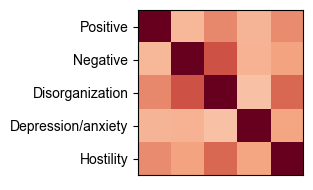

In [78]:
corr = df_c[['c1','c2','c3','c4','c5']].corr()

fig, ax = plt.subplots(figsize=(4,2))

ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks([])
ax.set_yticks(np.arange(5))
ax.set_yticklabels(label[:5])

fig.tight_layout()
fig.savefig('../figures/panss_factors_corr.png', transparent=True, dpi=300)

In [81]:
data = data_spl.copy()
df_test = df[df.columns[8:]]
for i in range(68):
    df_test['node_'+str(i+1)] = data[pos][:,i]
df_test

,age,sex,L_bankssts_thickavg,L_caudalanteriorcingulate_thickavg,L_caudalmiddlefrontal_thickavg,L_cuneus_thickavg,L_entorhinal_thickavg,L_fusiform_thickavg,L_inferiorparietal_thickavg,L_inferiortemporal_thickavg,...,node_59,node_60,node_61,node_62,node_63,node_64,node_65,node_66,node_67,node_68
0,41.0,1.0,2.632441,2.416048,2.364020,1.778040,3.197748,2.328022,2.429816,2.699748,...,0.603175,0.427002,0.508844,0.370068,0.355054,0.446429,0.863919,0.000000,0.446429,0.355054
1,19.0,1.0,2.203167,2.675005,2.526137,1.784654,3.253637,2.730261,2.501018,2.663209,...,0.585162,0.578746,0.462644,0.563218,0.431942,0.212202,0.367816,0.000000,0.715551,0.268199
2,30.0,2.0,2.696212,2.665986,2.699158,1.842757,3.587320,2.875282,2.509015,2.959093,...,0.600726,0.421739,0.842595,0.421739,0.405594,0.908009,0.330564,0.000000,0.842595,0.294473
3,36.0,2.0,2.782656,2.912112,2.640616,1.899454,3.763584,2.899055,2.563860,3.019694,...,0.257477,0.643692,0.328283,0.246212,0.590333,0.627600,0.687946,0.000000,0.531046,0.257477
4,23.0,1.0,2.367214,3.101935,2.512627,1.936791,3.663129,2.793973,2.510640,2.886898,...,0.777530,0.677083,0.904762,0.113095,0.486111,0.698529,0.698529,0.032624,1.000000,0.113095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,24.0,2.0,2.184145,2.355027,2.515917,1.733082,3.222971,2.559422,2.208292,2.543331,...,0.516717,0.257190,0.455927,0.470325,0.516717,0.391114,0.361563,0.093523,0.510141,0.212766
877,26.0,2.0,1.938685,2.431065,2.275468,1.769256,2.742593,2.424476,2.275811,2.146442,...,0.100251,0.533196,0.854409,0.599845,0.533196,0.808394,0.100251,0.000000,0.714286,0.100251
878,23.0,2.0,2.455068,2.648965,2.528694,1.730226,3.349157,2.670693,2.451360,2.723431,...,0.579710,1.000000,0.449938,0.364450,0.607417,0.817009,0.772756,0.000000,0.668159,0.772756
879,22.0,2.0,2.448957,2.911126,2.571673,1.945367,3.139510,2.798537,2.701179,2.685632,...,0.197932,0.765686,0.356569,0.486150,0.513158,0.329887,0.609792,0.177632,0.604793,0.175940


In [ ]:
data = data_spl.copy()
data_str = 'spl'
n_boot = 5000

df_test = df[df.columns[8:]]
for i in range(68):
    df_test['node_'+str(i+1)] = data[pos][:,i]

pls_ref = PLSRegression(n_components=1)
pls_ref.fit(df_test[np.concatenate([df_test.columns[:2], df_test.columns[70:100]])], 
            df_test[df_test.columns[100:]])

bootstrap_samples = [df_test.sample(n=len(df_test), replace=True) for _ in range(n_boot)]

rp = np.zeros((n_boot, 2))
x_loading = np.zeros((n_boot, 32))
y_loading = np.zeros((n_boot, 68))

for i in range(n_boot):
  pls = PLSRegression(n_components=1)
  pls.fit(bootstrap_samples[i][df_test.columns[:32]], bootstrap_samples[i][df_test.columns[32:]])
  
  rp[i] = ss.pearsonr(pls.x_scores_[:,0], pls.y_scores_[:,0])
  x_loading[i] = pls.x_loadings_[:,0]
  y_loading[i] = pls.y_loadings_[:,0]

In [14]:
rp[:,0].mean(0), rp[:,0].mean(0)-1.645*rp[:,0].std(0), rp[:,0].mean(0)+1.645*rp[:,0].std(0), 2 * (1 - ss.norm.cdf(abs(rp[:,0].mean(0)/rp[:,0].std(0))))

(0.359114377614124, 0.3091179894002413, 0.4091107658280067, 0.0)

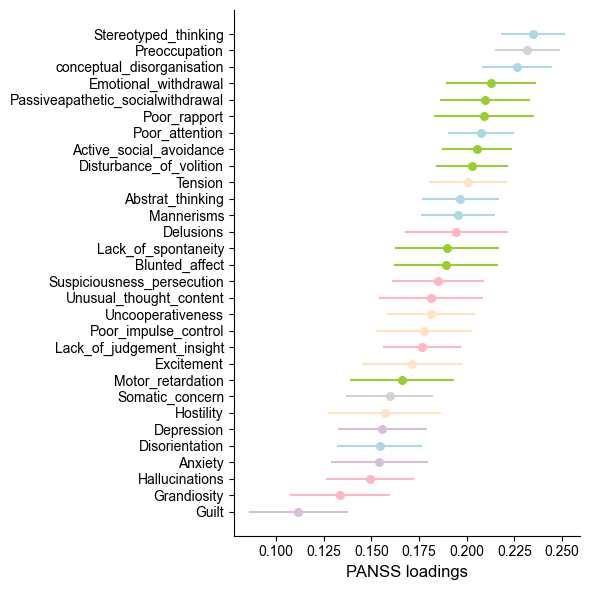

In [15]:
rank_t=x_loading[:,2:].mean(0).argsort()

fig, ax = plt.subplots(figsize=(6,6))
for i in range(len(pnass_label)):
  ax.scatter(x_loading[:,2:].mean(0)[rank_t][i],i, s=30, color=np.array(pnass_label)[rank_t][i])
  ax.plot([(x_loading[:,2:].mean(0)-1.645*x_loading[:,2:].std(0))[rank_t][i], 
          (x_loading[:,2:].mean(0)+1.645*x_loading[:,2:].std(0))[rank_t][i]],
          [i, i], c=np.array(pnass_label)[rank_t][i])
  #ax.scatter(pls2.x_loadings_[:,0][3:][rank_t][i],i, s=(i+2)*2, color=np.array(pnass_label)[rank_t][i], edgecolors='grey')

#ax.set_xticks([0,0.1,0.2])

ax.set_yticks(range(len(pnass_label)))
ax.set_yticklabels(np.array(fp.panss_item)[rank_t])
ax.set_xlabel('PANSS loadings')

#ax.vlines(x=0, ymin=-0.5,ymax=29.5, color='grey',ls='-.')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()
fig.savefig('../figures/panss_behavior_'+data_str+'.png', transparent=True, dpi=300)

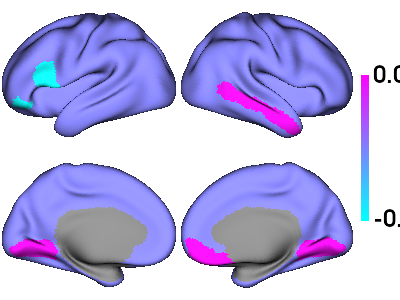

In [16]:
atlas = np.loadtxt('../src/fs_LR.dk.txt')

tmp_p = [2 * (1 - ss.norm.cdf(abs(y_loading[:,i].mean()/y_loading[:,i].std()))) for i in range(68)]
tmp = y_loading.mean(0)
df_save = pd.DataFrame()
df_save['Region'] = [label[:-9] for label in np.array(fp.region_list)]
df_save['Loading'] = tmp
df_save['p'] = tmp_p
df_save.to_csv('../results/panss_brain_'+data_str+'.csv', index=False)

tmp[np.array(tmp_p) > 0.1] = 0
tmp = [tmp]

plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='cool', color_range=(-0.0005,0.0005),layout_style = 'grid',
                display=True, filename='../figures/panss_brain_'+data_str+'.png')

In [17]:
df_test = df_c[df_c.columns[8:]]
for i in range(68):
    df_test['node_'+str(i+1)] = data[pos][:,i]

bootstrap_samples = [df_test.sample(n=len(df_test), replace=True) for _ in range(n_boot)]

rp = np.zeros((n_boot, 2))
x_loading = np.zeros((n_boot, 7))
y_loading = np.zeros((n_boot, 68))

pls_ref = PLSRegression(n_components=1)
pls_ref.fit(df_test[df_test.columns[:7]], df_test[df_test.columns[7:]])

for i in range(n_boot):
  pls = PLSRegression(n_components=1)
  pls.fit(bootstrap_samples[i][df_test.columns[:7]], bootstrap_samples[i][df_test.columns[7:]])
  
  rp[i] = ss.pearsonr(pls.x_scores_[:,0], pls.y_scores_[:,0])
  if ss.pearsonr(pls.y_loadings_[:,0], pls_ref.y_loadings_[:,0])[0] < 0:
    x_loading[i] = -pls.x_loadings_[:,0]
    y_loading[i] = -pls.y_loadings_[:,0]
  else:
    x_loading[i] = pls.x_loadings_[:,0]
    y_loading[i] = pls.y_loadings_[:,0]

In [18]:
rp[:,0].mean(0), rp[:,0].mean(0)-1.96*rp[:,0].std(0), rp[:,0].mean(0)+1.96*rp[:,0].std(0), 2 * (1 - ss.norm.cdf(abs(rp[:,0].mean(0)/rp[:,0].std(0))))

(0.36231326574945777, 0.30394711444224404, 0.4206794170566715, 0.0)

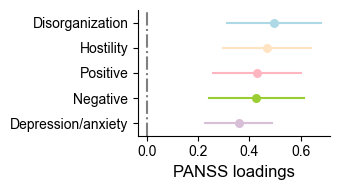

In [19]:
tmp=x_loading[:,2:] # flip loadings for G1
rank_t=tmp.mean(0).argsort()

fig, ax = plt.subplots(figsize=(3.5,2))

for i in range(5):
  ax.scatter(tmp.mean(0)[rank_t][i],i, s=30, color=cmap_5[rank_t][i])
  ax.plot([(tmp.mean(0)-1.645*tmp.std(0))[rank_t][i], 
          (tmp.mean(0)+1.645*tmp.std(0))[rank_t][i]],
          [i, i], c=cmap_5[rank_t][i])
  #ax.scatter(pls2.x_loadings_[:,0][3:][rank_t][i],i, s=(i+2)*2, color=np.array(pnass_label)[rank_t][i], edgecolors='grey')
  
ax.vlines(x=0, ymin=-0.5,ymax=4.5, color='grey',ls='-.')
ax.set_ylim(-0.5,4.5)
ax.set_yticks(range(5))
ax.set_yticklabels(np.array(label)[:5][rank_t])

#ax.vlines(x=0, ymin=-0.5,ymax=29.5, color='grey',ls='-.')
ax.set_xlabel('PANSS loadings')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.tight_layout()
fig.savefig('../figures/panss_behavior_'+data_str+'_cate.png', transparent=True, dpi=300)

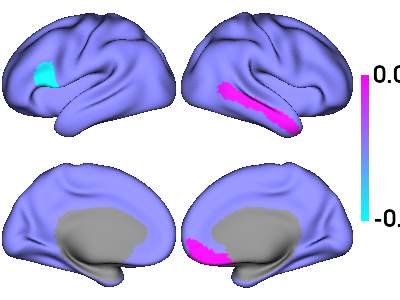

In [20]:
tmp_p = [2 * (1 - ss.norm.cdf(abs(y_loading[:,i].mean()/y_loading[:,i].std()))) for i in range(68)]
tmp = y_loading.mean(0)
df_save = pd.DataFrame()
df_save['Region'] = [label[:-9] for label in np.array(fp.region_list)]
df_save['Loading'] = tmp
df_save['p'] = tmp_p
df_save.to_csv('../results/panss_brain_'+data_str+'_cate.csv', index=False)

tmp[np.array(tmp_p) > 0.1] = 0
tmp = [tmp]

plot = [None] * len(tmp)
for i in range(len(tmp)):
  plot[i] = atlas.copy()
  for j in range(68):
    plot[i][atlas==j+1] = tmp[i][j]
  plot[i][atlas==0] = np.nan

fp.plot_surface(data=plot, size=(400,300*len(tmp)), cmap='cool', color_range=(-0.05,0.05),layout_style = 'grid',
                display=True, filename='../figures/panss_brain_'+data_str+'_cate.png')

## subtypes

In [87]:
df_scz = df_impute[df_impute.DX==1].reset_index(drop=True)
full = np.array(df_scz.site + df_scz.ID)
clinic = np.array(df_pnass.site + df_pnass.ID)
pos = []
mask=np.ones(len(clinic))
for i in range(len(clinic)):
  try:
    pos.append(np.where(full==clinic[i])[0][0])
  except:
    mask[i] = 0

In [94]:
subtype = np.loadtxt('../results/enigma_subtype.txt')
#subtype[subtype==-1] = 0
df = pd.DataFrame()
df['subtype'] = subtype[pos]
df[df_scz.columns] = df_scz.loc[pos][df_scz.columns].reset_index(drop=True)
df[df_pnass.columns[2:]] = df_pnass.loc[mask==1,df_pnass.columns[2:]].reset_index(drop=True)
tmp = np.array(df[df.columns[79:]])
for i in range(6):
  df['c'+str(i+1)] = tmp[:,np.array(pnass)==i+1].sum(axis=1)
df['subtype_age'] = df['age'] * df['subtype']
df['subtype_sex'] = df['sex'] * df['subtype']
df

,subtype,site,ID,AO,IQ,CPZ,sans_total,site_num,DX,age,...,PANSS29,PANSS30,c1,c2,c3,c4,c5,c6,subtype_age,subtype_sex
0,-1.0,01_Zurish,subj_102,31.00,NaN,150.00,41,1.0,1.0,41.0,...,1,2,15.0,17.0,6.0,3.0,5.0,2.0,-41.0,-1.0
1,-1.0,01_Zurish,subj_104,16.80,NaN,150.00,13,1.0,1.0,19.0,...,1,3,7.0,13.0,7.0,6.0,6.0,2.0,-19.0,-1.0
2,-1.0,01_Zurish,subj_106,25.00,NaN,150.00,44,1.0,1.0,30.0,...,1,5,14.0,25.0,12.0,3.0,10.0,2.0,-30.0,-2.0
3,1.0,01_Zurish,subj_107,29.00,NaN,300.00,9,1.0,1.0,36.0,...,1,2,12.0,12.0,6.0,3.0,5.0,2.0,36.0,2.0
4,-1.0,01_Zurish,subj_108,22.70,NaN,333.33,27,1.0,1.0,23.0,...,1,3,6.0,14.0,6.0,6.0,5.0,2.0,-23.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,-1.0,40_RSCZ,SCH42,23.38,NaN,NaN,NaN,40.0,1.0,24.0,...,2,3,13.0,19.0,14.0,7.0,6.0,4.0,-24.0,-2.0
876,1.0,40_RSCZ,SCH43,26.00,NaN,NaN,NaN,40.0,1.0,26.0,...,1,1,8.0,17.0,13.0,5.0,6.0,4.0,26.0,2.0
877,-1.0,40_RSCZ,SCH44,23.09,NaN,NaN,NaN,40.0,1.0,23.0,...,2,1,6.0,11.0,10.0,6.0,5.0,5.0,-23.0,-2.0
878,1.0,40_RSCZ,SCH45,21.44,NaN,NaN,NaN,40.0,1.0,22.0,...,3,3,16.0,27.0,16.0,3.0,6.0,5.0,22.0,2.0


In [96]:
ss.ttest_ind(df_scz[subtype==-1].age, df_scz[subtype==1].age)

TtestResult(statistic=1.6793395633798525, pvalue=0.09316485147980921, df=3956.0)

In [97]:
duration = np.array((df_scz['age'] - df_scz['AO']))
duration[duration<0] = np.nan
df_scz['duration'] = duration
ss.ttest_ind(df_scz[subtype==-1].duration.dropna(), df_scz[subtype==1].duration.dropna())

TtestResult(statistic=0.6242685925294782, pvalue=0.5324957222806254, df=3199.0)

In [98]:
ss.chi2_contingency(pd.crosstab(subtype, df_scz.sex))

Chi2ContingencyResult(statistic=0.6647088136397016, pvalue=0.41490246055196844, dof=1, expected_freq=array([[1326.11167256,  798.88832744],
       [1143.88832744,  689.11167256]]))

[] []


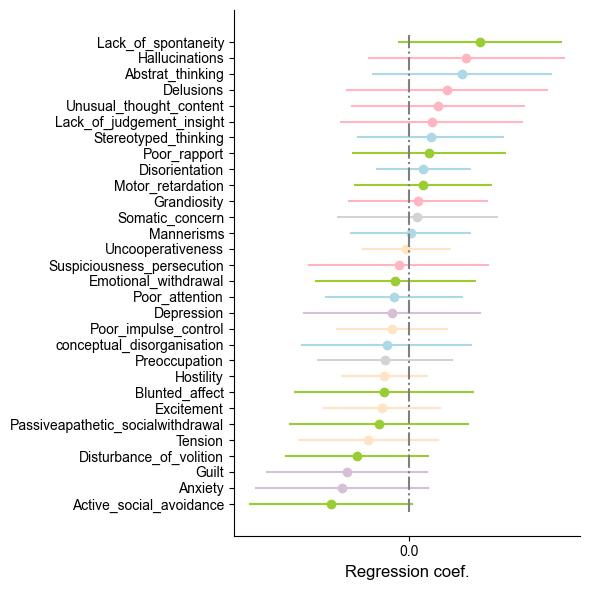

In [99]:
corr = np.zeros((30,5)) # 5 including beta, 95%CI, t, p
for i in range(30):
  df_test = df[['subtype','age','sex']]
  df_test = add_constant(df_test)
  model = OLS(df['PANSS'+str(i+1)], df_test).fit()
  corr[i,0] = model.params[1]
  corr[i,1] = model.conf_int()[0][1]
  corr[i,2] = model.conf_int()[1][1]
  corr[i,3] = model.tvalues[1]
  corr[i,4] = model.pvalues[1]

fig, ax = plt.subplots(figsize=(6,6))
rank = corr[:,0].argsort()
print(np.array(fp.panss_item)[corr[:,4]<0.05], corr[:,3:][corr[:,4]<0.05])
for i in range(30):
  ax.plot(corr[rank][i,0], i, color=np.array(pnass_label)[rank][i], marker='o')
  ax.plot([corr[rank][i,1], corr[rank][i,2]],
          [i, i], c=np.array(pnass_label)[rank][i])
  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xticks([-0.4,-0.2,0,0.2,0.4])
ax.set_yticks(range(30))
ax.set_yticklabels(np.array(fp.panss_item)[rank])
ax.set_xlabel('Regression coef.')
ax.vlines(x=0, ymin=-0.5,ymax=29.5, color='grey',ls='-.')

fig.tight_layout()
fig.savefig('../figures/panss_subtype.png', transparent=True, dpi=300)

['Delusions' 'conceptual_disorganisation' 'Grandiosity' 'Anxiety' 'Guilt'
 'Mannerisms' 'Unusual_thought_content' 'Preoccupation'
 'Active_social_avoidance'] [[2.64791807 0.00824484]
 [2.13855012 0.03274877]
 [2.41091902 0.01611781]
 [2.30484833 0.02140861]
 [2.25450087 0.02441153]
 [2.12295927 0.03403778]
 [2.60479974 0.00934897]
 [2.71336941 0.00679132]
 [2.18954639 0.0288209 ]]


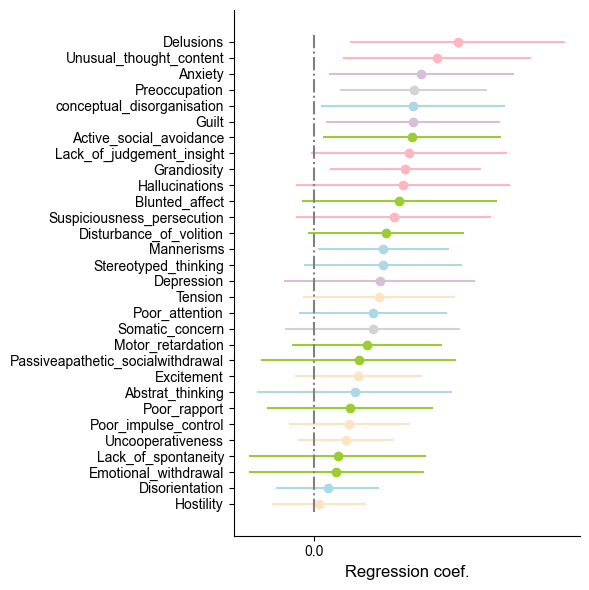

In [100]:
corr = np.zeros((30,5)) # 5 including beta, 95%CI, t, p
for i in range(30):
  df_test = df[['subtype_age','subtype','age','sex','site_num']]
  df_test = add_constant(df_test)
  model = OLS(df['PANSS'+str(i+1)], df_test).fit()
  corr[i,0] = model.params[1]
  corr[i,1] = model.conf_int()[0][1]
  corr[i,2] = model.conf_int()[1][1]
  corr[i,3] = model.tvalues[1]
  corr[i,4] = model.pvalues[1]

fig, ax = plt.subplots(figsize=(6,6))
rank = corr[:,0].argsort()
print(np.array(fp.panss_item)[corr[:,4]<0.05], corr[:,3:][corr[:,4]<0.05])
for i in range(30):
  ax.plot(corr[rank][i,0], i, color=np.array(pnass_label)[rank][i], marker='o')
  ax.plot([corr[rank][i,1], corr[rank][i,2]],
          [i, i], c=np.array(pnass_label)[rank][i])
  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xticks([-0.4,-0.2,0,0.2,0.4])
ax.set_yticks(range(30))
ax.set_yticklabels(np.array(fp.panss_item)[rank])
ax.set_xlabel('Regression coef.')
ax.vlines(x=0, ymin=-0.5,ymax=29.5, color='grey',ls='-.')

fig.tight_layout()
fig.savefig('../figures/panss_subtype_age.png', transparent=True, dpi=300)

[] []


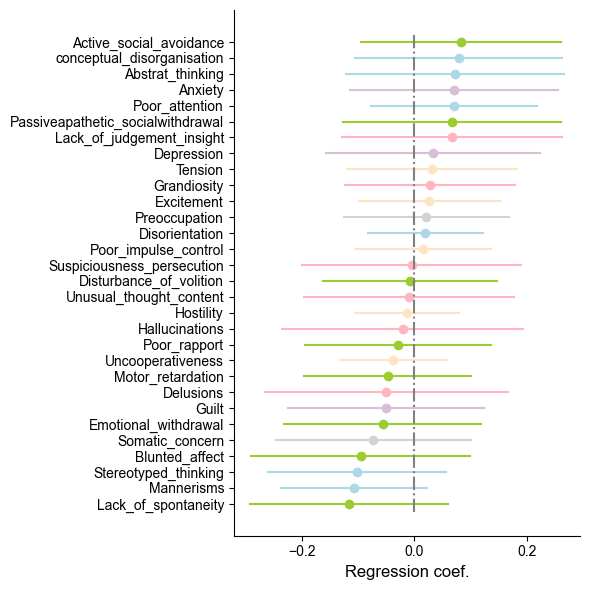

In [101]:
corr = np.zeros((30,5)) # 5 including beta, 95%CI, t, p
for i in range(30):
  df_test = df[['subtype_sex','subtype','age','sex','site_num']]
  df_test = add_constant(df_test)
  model = OLS(df['PANSS'+str(i+1)], df_test).fit()
  corr[i,0] = model.params[1]
  corr[i,1] = model.conf_int()[0][1]
  corr[i,2] = model.conf_int()[1][1]
  corr[i,3] = model.tvalues[1]
  corr[i,4] = model.pvalues[1]

fig, ax = plt.subplots(figsize=(6,6))
rank = corr[:,0].argsort()
print(np.array(fp.panss_item)[corr[:,4]<0.05], corr[:,3:][corr[:,4]<0.05])
for i in range(30):
  ax.plot(corr[rank][i,0], i, color=np.array(pnass_label)[rank][i], marker='o')
  ax.plot([corr[rank][i,1], corr[rank][i,2]],
          [i, i], c=np.array(pnass_label)[rank][i])
  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xticks([-0.4,-0.2,0,0.2,0.4])
ax.set_yticks(range(30))
ax.set_yticklabels(np.array(fp.panss_item)[rank])
ax.set_xlabel('Regression coef.')
ax.vlines(x=0, ymin=-0.5,ymax=29.5, color='grey',ls='-.')

fig.tight_layout()
fig.savefig('../figures/panss_subtype_sex.png', transparent=True, dpi=300)

[] []


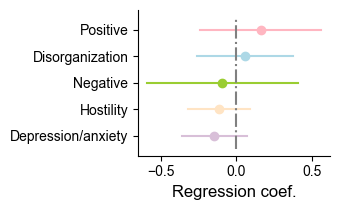

In [102]:
corr = np.zeros((5,5)) # 5 including beta, 95%CI, t, p
for i in range(5):
  df_test = df[['subtype','age','sex','site_num']]
  df_test = add_constant(df_test)
  model = sm.GLM(df['c'+str(i+1)], df_test).fit()
  corr[i,0] = model.params[1]
  corr[i,1] = model.conf_int()[0][1]
  corr[i,2] = model.conf_int()[1][1]
  corr[i,3] = model.tvalues[1]
  corr[i,4] = model.pvalues[1]

fig, ax = plt.subplots(figsize=(3.5,2.2))
rank = corr[:,0].argsort()
print(np.array(label)[:5][corr[:,4]<0.1], corr[:,3:][corr[:,4]<0.05])
for i in range(5):
  ax.plot(corr[rank][i,0], i, color=np.array(cmap_5)[rank][i], marker='o')
  ax.plot([corr[rank][i,1], corr[rank][i,2]],
          [i, i], c=np.array(cmap_5)[rank][i])
  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

#ax.set_xticks([0, 1])
#ax.set_xticklabels(['0', '1'])
ax.set_yticks(range(5))
ax.set_yticklabels(np.array(label)[:5][rank])
ax.set_xlabel('Regression coef.')
ax.vlines(x=0, ymin=-0.5,ymax=4.5, color='grey',ls='-.')

fig.tight_layout()
fig.savefig('../figures/panss_subtype_cate.png', transparent=True, dpi=300)

In [103]:
# disorganization
[[df['c3'][df_test['subtype']==-1].mean(), df['c3'][df_test['subtype']==-1].std()],
[df['c3'][df_test['subtype']==1].mean(), df['c3'][df_test['subtype']==1].std()],
[corr[2,3], corr[2,4]]]


[[10.980519480519481, 4.847081255010922],
 [10.9688995215311, 4.793229561096722],
 [0.36676418738528405, 0.7137949231481437]]

['Positive' 'Disorganization' 'Depression/anxiety'] [[2.94861968 0.00319197]
 [2.09609782 0.03607351]
 [2.39889695 0.01644454]]


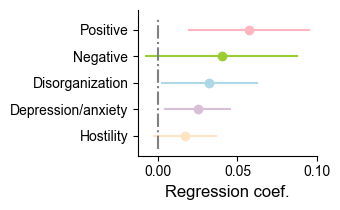

In [104]:
corr = np.zeros((5,5)) # 5 including beta, 95%CI, t, p
for i in range(5):
  df_test = df[['subtype_age','subtype','age','sex','site_num']]
  df_test = add_constant(df_test)
  model = sm.GLM(df['c'+str(i+1)], df_test).fit()
  corr[i,0] = model.params[1]
  corr[i,1] = model.conf_int()[0][1]
  corr[i,2] = model.conf_int()[1][1]
  corr[i,3] = model.tvalues[1]
  corr[i,4] = model.pvalues[1]
fig, ax = plt.subplots(figsize=(3.5,2.2))
rank = corr[:,0].argsort()
print(np.array(label)[:5][corr[:,4]<0.05], corr[:,3:][corr[:,4]<0.05])
for i in range(5):
  ax.plot(corr[rank][i,0], i, color=np.array(cmap_5)[rank][i], marker='o')
  ax.plot([corr[rank][i,1], corr[rank][i,2]],
          [i, i], c=np.array(cmap_5)[rank][i])
  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

#ax.set_xticks([0, 0.05])
#ax.set_xticklabels(['0', '0.05'])
ax.set_yticks(range(5))
ax.set_yticklabels(np.array(label)[:5][rank])
ax.set_xlabel('Regression coef.')
ax.vlines(x=0, ymin=-0.5,ymax=4.5, color='grey',ls='-.')

fig.tight_layout()
fig.savefig('../figures/panss_subtype_age_cate.png', transparent=True, dpi=300)

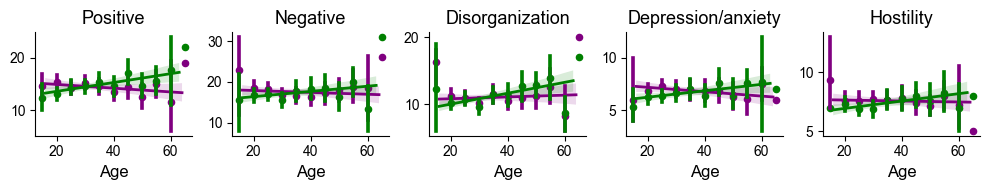

In [105]:
fig, ax = plt.subplots(1,5, figsize=(10,2))

for i in range(5):

    sns.regplot(data=df[df.subtype==-1], y="c"+str(i+1), x="age", ax=ax[i],
                x_bins=np.arange(15, 70, 5), color='purple',
                scatter_kws={'s':20}, line_kws={'lw':2})
    sns.regplot(data=df[df.subtype==1], y="c"+str(i+1), x="age", ax=ax[i],
                x_bins=np.arange(15, 70, 5), color='green',
                scatter_kws={'s':20}, line_kws={'lw':2})

    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)

    ax[i].set_xlabel('Age')
    ax[i].set_ylabel('')
    ax[i].set_title(label[i], fontsize=13)

fig.tight_layout()
fig.savefig('../figures/panss_subtype_age_inter_cate.png', transparent=True, dpi=300)

In [106]:
for i in range(6):
    print("s1",label[i], ss.pearsonr(df[df.subtype==1]['c'+str(i+1)], df[df.subtype==1]['age']))
    print("s2",label[i], ss.pearsonr(df[df.subtype==-1]['c'+str(i+1)], df[df.subtype==-1]['age']))

s1 Positive PearsonRResult(statistic=0.14592532648857454, pvalue=0.002784848681552133)
s2 Positive PearsonRResult(statistic=-0.06104411999562764, pvalue=0.19027674181270918)
s1 Negative PearsonRResult(statistic=0.08616939937067378, pvalue=0.07845253557556488)
s2 Negative PearsonRResult(statistic=-0.032039986953537096, pvalue=0.4920926915132709)
s1 Disorganization PearsonRResult(statistic=0.17705135526324284, pvalue=0.0002750162676477007)
s2 Disorganization PearsonRResult(statistic=0.02868494258654087, pvalue=0.5385443026368214)
s1 Depression/anxiety PearsonRResult(statistic=0.10226744559411495, pvalue=0.036610220536661714)
s2 Depression/anxiety PearsonRResult(statistic=-0.0655283825871944, pvalue=0.1596720742616711)
s1 Hostility PearsonRResult(statistic=0.11172793336770587, pvalue=0.022336299243984847)
s2 Hostility PearsonRResult(statistic=-0.013489986528387204, pvalue=0.772440623552639)
s1 Non-categorized PearsonRResult(statistic=0.1803634665269751, pvalue=0.00020977688039828534)
s2 N

[] []


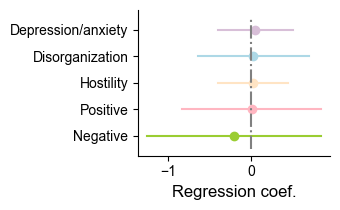

In [107]:
corr = np.zeros((5,5)) # 5 including beta, 95%CI, t, p
for i in range(5):
  df_test = df[['subtype_sex','subtype','age','sex','site_num']]
  df_test = add_constant(df_test)
  model = sm.GLM(df['c'+str(i+1)], df_test).fit()
  corr[i,0] = model.params[1]
  corr[i,1] = model.conf_int()[0][1]
  corr[i,2] = model.conf_int()[1][1]
  corr[i,3] = model.tvalues[1]
  corr[i,4] = model.pvalues[1]

fig, ax = plt.subplots(figsize=(3.5,2.2))
rank = corr[:,0].argsort()
print(np.array(label)[:5][corr[:,4]<0.1], corr[:,3:][corr[:,4]<0.05])
for i in range(5):
  ax.plot(corr[rank][i,0], i, color=np.array(cmap_5)[rank][i], marker='o')
  ax.plot([corr[rank][i,1], corr[rank][i,2]],
          [i, i], c=np.array(cmap_5)[rank][i])
  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

#ax.set_xticks([-1, 0, 1])
ax.set_yticks(range(5))
ax.set_yticklabels(np.array(label)[:5][rank])
ax.set_xlabel('Regression coef.')
ax.vlines(x=0, ymin=-0.5,ymax=4.5, color='grey',ls='-.')

fig.tight_layout()
fig.savefig('../figures/panss_subtype_sex_cate.png', transparent=True, dpi=300)

In [111]:
ss.pearsonr(df[df.subtype==1].R_rostralanteriorcingulate_thickavg, df[df.subtype==1].age)

PearsonRResult(statistic=-0.26480282017268614, pvalue=3.882614576407301e-08)

In [112]:
ss.pearsonr(df[df.subtype==-1].R_rostralanteriorcingulate_thickavg, df[df.subtype==-1].age)

PearsonRResult(statistic=-0.3378778204716493, pvalue=8.435468165320547e-14)

In [113]:
for i in range(6):
    print("s1",label[i], ss.pearsonr(df[df.subtype==1]['c'+str(i+1)], df[df.subtype==1]['R_rostralanteriorcingulate_thickavg']))
    print("s2",label[i], ss.pearsonr(df[df.subtype==-1]['c'+str(i+1)], df[df.subtype==-1]['R_rostralanteriorcingulate_thickavg']))

s1 Positive PearsonRResult(statistic=0.0058954514014538835, pvalue=0.9043461919173141)
s2 Positive PearsonRResult(statistic=-0.0014934784349996911, pvalue=0.9744607601953315)
s1 Negative PearsonRResult(statistic=-0.04640855984593078, pvalue=0.3438966860028429)
s2 Negative PearsonRResult(statistic=-0.030505371654313863, pvalue=0.5130705207142471)
s1 Disorganization PearsonRResult(statistic=-0.10130056609313387, pvalue=0.0384316476800625)
s2 Disorganization PearsonRResult(statistic=-0.02719302343615767, pvalue=0.5598823168292898)
s1 Depression/anxiety PearsonRResult(statistic=0.02056842227089075, pvalue=0.6749914364721683)
s2 Depression/anxiety PearsonRResult(statistic=0.07839567825431897, pvalue=0.09236008110980522)
s1 Hostility PearsonRResult(statistic=0.05378833196774724, pvalue=0.27255119636750935)
s2 Hostility PearsonRResult(statistic=-0.003522702037806415, pvalue=0.9398067731025344)
s1 Non-categorized PearsonRResult(statistic=-0.008096853541342597, pvalue=0.8689065579530827)
s2 Non

In [114]:
import statsmodels.api as sm
from statsmodels.stats.mediation import Mediation

In [118]:
df_test = df[df.subtype==1].reset_index(drop=True)
mediator_model = sm.OLS(df_test["R_rostralanteriorcingulate_thickavg"], sm.add_constant(df_test[["age"]]))
outcome_model = sm.OLS(df_test["c3"], sm.add_constant(df_test[["age","R_rostralanteriorcingulate_thickavg"]]))
med = Mediation(outcome_model, mediator_model, "age", "R_rostralanteriorcingulate_thickavg")
result = med.fit()
result.summary()

,Estimate,Lower CI bound,Upper CI bound,P-value
ACME (control),0.007930,-0.037515,0.070383,0.758
ACME (treated),0.007930,-0.037515,0.070383,0.758
ADE (control),0.073802,0.028686,0.117544,0.002
ADE (treated),0.073802,0.028686,0.117544,0.002
Total effect,0.081732,0.014042,0.151053,0.016
Prop. mediated (control),0.054019,-1.244543,0.579131,0.742
Prop. mediated (treated),0.054019,-1.244543,0.579131,0.742
ACME (average),0.007930,-0.037515,0.070383,0.758
ADE (average),0.073802,0.028686,0.117544,0.002
Prop. mediated (average),0.054019,-1.244543,0.579131,0.742
